# Starbucks Capstone Challenge

## Project Overview

This project uses the simulated Starbucks Rewards mobile app data to understand which customers respond to which offers. Starbucks periodically sends users one of three offer types: buy-one-get-one (BOGO), discount, or informational messages. Customers can receive, view, complete, and transact during the offer validity period.

The business goal is to improve targeting. A useful model should estimate whether a customer is likely to respond to a specific offer before the offer is sent, and the analysis should identify demographic groups that respond best to each offer type.

## Problem Statement

For every `offer received` event, predict whether that customer will respond successfully to the offer inside its validity window.

A response is defined as follows:

- BOGO and discount offers: the customer views the offer and then completes that same offer before it expires.
- Informational offers: the customer views the offer and then makes a transaction before it expires.

This converts the event stream into a supervised binary classification problem. Each row is one offer exposure, the target is `successful_response`, and the model only uses demographic and offer attributes that would be available before sending the offer.

## Metrics and Benchmark

The primary metric is F1 score because the positive class is the set of customers who respond, and both false positives and false negatives matter for a targeting system. Accuracy is also reported for interpretability, and ROC-AUC is reported to evaluate ranking quality across classification thresholds.

The benchmark is a majority-class `DummyClassifier`. A model is useful only if it improves materially over this simple baseline on the held-out test set.

In [1]:
import json
import math
import os
import warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42
DATA_DIR = Path('data')

# Data Sets

The data is contained in three files:

- `portfolio.json`: offer ids and offer metadata.
- `profile.json`: customer demographics.
- `transcript.json`: events for transactions, offers received, offers viewed, and offers completed.

In [2]:
portfolio = pd.read_json(DATA_DIR / 'portfolio.json', orient='records', lines=True)
profile = pd.read_json(DATA_DIR / 'profile.json', orient='records', lines=True)
transcript = pd.read_json(DATA_DIR / 'transcript.json', orient='records', lines=True)

print('portfolio:', portfolio.shape)
print('profile:', profile.shape)
print('transcript:', transcript.shape)

display(portfolio.head())
display(profile.head())
display(transcript.head())

portfolio: (10, 6)
profile: (17000, 5)
transcript: (306534, 4)
   reward  ...                                id
0      10  ...  ae264e3637204a6fb9bb56bc8210ddfd
1      10  ...  4d5c57ea9a6940dd891ad53e9dbe8da0
2       0  ...  3f207df678b143eea3cee63160fa8bed
3       5  ...  9b98b8c7a33c4b65b9aebfe6a799e6d9
4       5  ...  0b1e1539f2cc45b7b9fa7c272da2e1d7

[5 rows x 6 columns]
  gender  age                                id  became_member_on    income
0   None  118  68be06ca386d4c31939f3a4f0e3dd783          20170212       NaN
1      F   55  0610b486422d4921ae7d2bf64640c50b          20170715  112000.0
2   None  118  38fe809add3b4fcf9315a9694bb96ff5          20180712       NaN
3      F   75  78afa995795e4d85b5d9ceeca43f5fef          20170509  100000.0
4   None  118  a03223e636434f42ac4c3df47e8bac43          20170804       NaN
                             person  ... time
0  78afa995795e4d85b5d9ceeca43f5fef  ...    0
1  a03223e636434f42ac4c3df47e8bac43  ...    0
2  e2127556f4f64592b11af22d

## Initial Data Exploration

The three source tables use hashed customer and offer identifiers. The profile table contains missing demographics represented by `gender = None`, `income = NaN`, and `age = 118`. Those records cannot be used for demographic analysis and are removed during preprocessing.

In [3]:
def count_duplicate_rows(df):
    # JSON string conversion makes nested dictionaries/lists hashable for this audit.
    normalized = df.applymap(lambda value: json.dumps(value, sort_keys=True) if isinstance(value, (dict, list)) else value)
    return int(normalized.duplicated().sum())

summary = pd.DataFrame({
    'rows': [len(portfolio), len(profile), len(transcript)],
    'columns': [portfolio.shape[1], profile.shape[1], transcript.shape[1]],
    'duplicate_rows': [count_duplicate_rows(portfolio), count_duplicate_rows(profile), count_duplicate_rows(transcript)],
}, index=['portfolio', 'profile', 'transcript'])

display(summary)

print('Transcript event counts:')
display(transcript['event'].value_counts().to_frame('count'))

print('Missing profile values:')
display(profile.isna().sum().to_frame('missing_count'))

print('Age 118 records:', int((profile['age'] == 118).sum()))

              rows  columns  duplicate_rows
portfolio       10        6               0
profile      17000        5               0
transcript  306534        4             397
Transcript event counts:
                  count
event                  
transaction      138953
offer received    76277
offer viewed      57725
offer completed   33579
Missing profile values:
                  missing_count
gender                     2175
age                           0
id                            0
became_member_on              0
income                     2175
Age 118 records: 2175


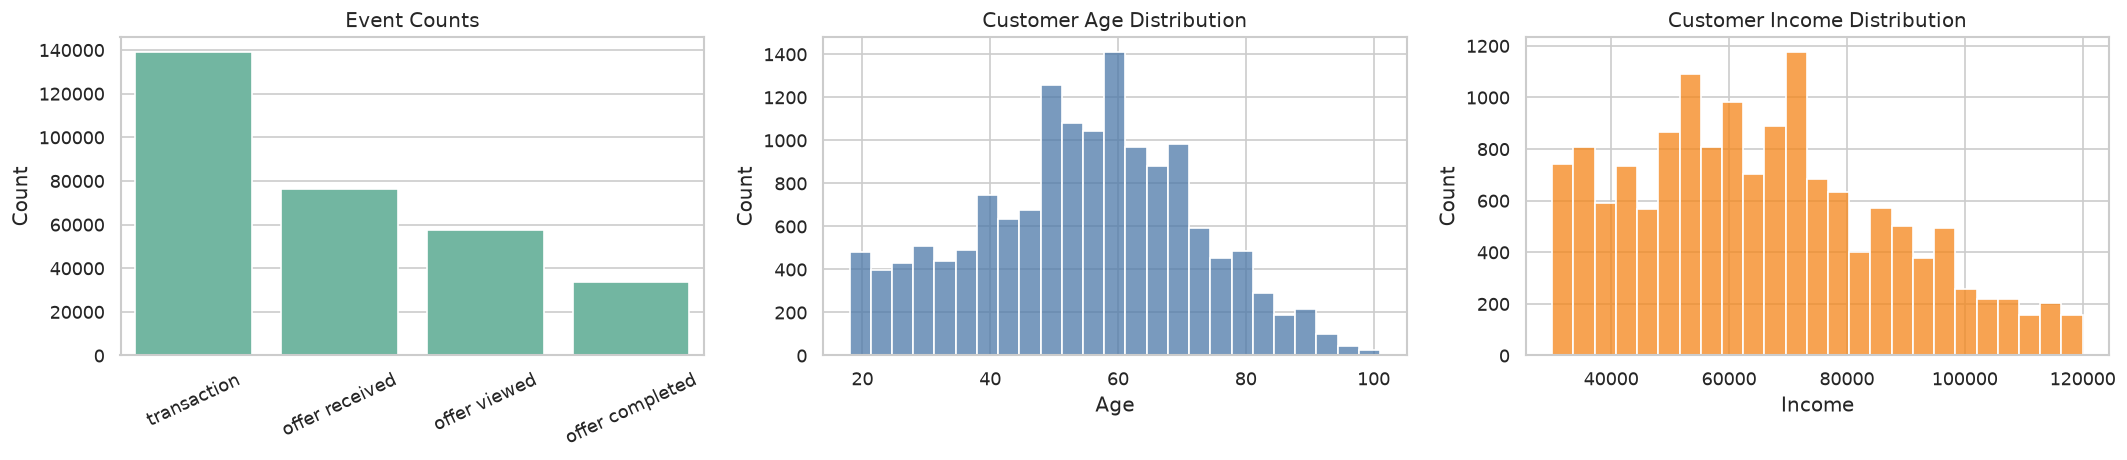

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=transcript, x='event', order=transcript['event'].value_counts().index, ax=axes[0])
axes[0].set_title('Event Counts')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

valid_profile = profile.query('age < 118 and income == income and gender == gender').copy()
sns.histplot(valid_profile['age'], bins=25, ax=axes[1], color='#4C78A8')
axes[1].set_title('Customer Age Distribution')
axes[1].set_xlabel('Age')

sns.histplot(valid_profile['income'], bins=25, ax=axes[2], color='#F58518')
axes[2].set_title('Customer Income Distribution')
axes[2].set_xlabel('Income')

plt.tight_layout()
plt.show()

## Algorithms and Techniques

The modeling workflow compares three approaches:

1. Majority-class dummy classifier as the benchmark.
2. Logistic regression as a linear, interpretable baseline.
3. Random forest classifier as the refined model, tuned with cross-validation.

Categorical features are one-hot encoded and numeric features are scaled for logistic regression. The random forest uses the same preprocessed matrix for a fair comparison.

# Data Preprocessing

The transcript `value` column stores dictionaries with different keys depending on event type. The next cells normalize those dictionaries, engineer offer metadata, clean demographics, and build one row per received offer.

In [5]:
def extract_offer_id(value):
    """Return the offer id from transcript value dictionaries."""
    if isinstance(value, dict):
        return value.get('offer id') or value.get('offer_id')
    return None


def extract_amount(value):
    if isinstance(value, dict):
        return value.get('amount', 0.0)
    return 0.0


def prepare_portfolio(portfolio_df):
    offers = portfolio_df.copy().rename(columns={'id': 'offer_id'})
    channel_dummies = offers['channels'].apply(lambda channels: pd.Series({f'channel_{c}': 1 for c in channels})).fillna(0).astype(int)
    offers = pd.concat([offers.drop(columns=['channels']), channel_dummies], axis=1)
    return offers


def prepare_profile(profile_df):
    customers = profile_df.copy().rename(columns={'id': 'person'})
    customers = customers[(customers['age'] < 118) & customers['gender'].notna() & customers['income'].notna()].copy()
    customers['became_member_on'] = pd.to_datetime(customers['became_member_on'].astype(str), format='%Y%m%d')
    max_member_date = customers['became_member_on'].max()
    customers['membership_tenure_days'] = (max_member_date - customers['became_member_on']).dt.days
    customers['membership_year'] = customers['became_member_on'].dt.year
    customers['age_group'] = pd.cut(
        customers['age'],
        bins=[17, 30, 45, 60, 75, 120],
        labels=['18-30', '31-45', '46-60', '61-75', '76+'],
    )
    customers['income_group'] = pd.cut(
        customers['income'],
        bins=[0, 45000, 65000, 85000, 200000],
        labels=['<45k', '45k-65k', '65k-85k', '85k+'],
    )
    return customers


def prepare_transcript(transcript_df):
    events = transcript_df.copy()
    events['offer_id'] = events['value'].apply(extract_offer_id)
    events['amount'] = events['value'].apply(extract_amount).astype(float)
    return events


offers = prepare_portfolio(portfolio)
customers = prepare_profile(profile)
events = prepare_transcript(transcript)

print('Clean customer rows:', customers.shape[0], 'of', profile.shape[0])
display(offers)
display(customers.head())
display(events.head())

Clean customer rows: 14825 of 17000
   reward  difficulty  duration  ... channel_mobile channel_social  channel_web
0      10          10         7  ...              1              1            0
1      10          10         5  ...              1              1            1
2       0           0         4  ...              1              0            1
3       5           5         7  ...              1              0            1
4       5          20        10  ...              0              0            1
5       3           7         7  ...              1              1            1
6       2          10        10  ...              1              1            1
7       0           0         3  ...              1              1            0
8       5           5         5  ...              1              1            1
9       2          10         7  ...              1              0            1

[10 rows x 9 columns]
   gender  age  ... age_group income_group
1       F   55  ..

## Response Label Construction

Offer validity is measured in hours because the transcript `time` column is in hours and `duration` is in days. For each received offer, the algorithm searches only that customer’s future events inside the offer window.

In [6]:
def build_offer_exposures(events_df, offers_df, customers_df):
    offer_lookup = offers_df.set_index('offer_id')
    customer_ids = set(customers_df['person'])
    received = events_df[(events_df['event'] == 'offer received') & events_df['person'].isin(customer_ids)].copy()
    received = received.merge(offers_df[['offer_id', 'duration', 'offer_type']], on='offer_id', how='left')
    received = received.reset_index(drop=True)

    grouped = {person: group.sort_values('time') for person, group in events_df.groupby('person')}
    records = []

    for exposure_id, row in received.iterrows():
        person = row['person']
        offer_id = row['offer_id']
        offer_type = row['offer_type']
        start = row['time']
        end = start + int(row['duration']) * 24
        person_events = grouped[person]
        window = person_events[(person_events['time'] >= start) & (person_events['time'] <= end)]

        viewed = window[
            (window['event'] == 'offer viewed')
            & (window['offer_id'] == offer_id)
            & (window['time'] >= start)
        ]
        viewed_offer = not viewed.empty
        first_view_time = viewed['time'].min() if viewed_offer else np.nan

        completed_offer = False
        transaction_after_view = False
        spend_after_view = 0.0
        transactions_after_view = 0

        if viewed_offer:
            after_view = window[window['time'] >= first_view_time]
            completed_offer = not after_view[
                (after_view['event'] == 'offer completed')
                & (after_view['offer_id'] == offer_id)
            ].empty
            transactions = after_view[after_view['event'] == 'transaction']
            transaction_after_view = not transactions.empty
            spend_after_view = transactions['amount'].sum()
            transactions_after_view = transactions.shape[0]

        if offer_type == 'informational':
            successful_response = viewed_offer and transaction_after_view
        else:
            successful_response = viewed_offer and completed_offer

        records.append({
            'exposure_id': exposure_id,
            'person': person,
            'offer_id': offer_id,
            'time': start,
            'offer_type': offer_type,
            'viewed_offer': int(viewed_offer),
            'completed_offer': int(completed_offer),
            'transaction_after_view': int(transaction_after_view),
            'spend_after_view': spend_after_view,
            'transactions_after_view': transactions_after_view,
            'successful_response': int(successful_response),
        })

    exposures = pd.DataFrame(records)
    exposures = exposures.merge(customers, on='person', how='left')
    exposures = exposures.merge(offers.drop(columns=['offer_type']), on='offer_id', how='left')
    return exposures

exposures = build_offer_exposures(events, offers, customers)
print('Modeling rows:', exposures.shape)
display(exposures.head())

display(exposures['successful_response'].value_counts(normalize=True).rename('proportion').to_frame())

Modeling rows: (66501, 26)
   exposure_id                            person  ... channel_social  channel_web
0            0  78afa995795e4d85b5d9ceeca43f5fef  ...              0            1
1            1  e2127556f4f64592b11af22de27a7932  ...              0            1
2            2  389bc3fa690240e798340f5a15918d5c  ...              1            1
3            3  2eeac8d8feae4a8cad5a6af0499a211d  ...              0            1
4            4  aa4862eba776480b8bb9c68455b8c2e1  ...              0            1

[5 rows x 26 columns]
                     proportion
successful_response            
0                      0.576818
1                      0.423182


The target rate is not perfectly balanced, so the evaluation includes F1 and ROC-AUC instead of relying only on accuracy.

      offer_type  ... avg_spend_after_view
3           bogo  ...            24.667538
0           bogo  ...            24.843078
2           bogo  ...            29.019704
1           bogo  ...            17.824287
7       discount  ...            49.712133
5       discount  ...            33.496469
6       discount  ...            18.819875
4       discount  ...            16.252113
9  informational  ...            10.860354
8  informational  ...             8.719899

[10 rows x 5 columns]


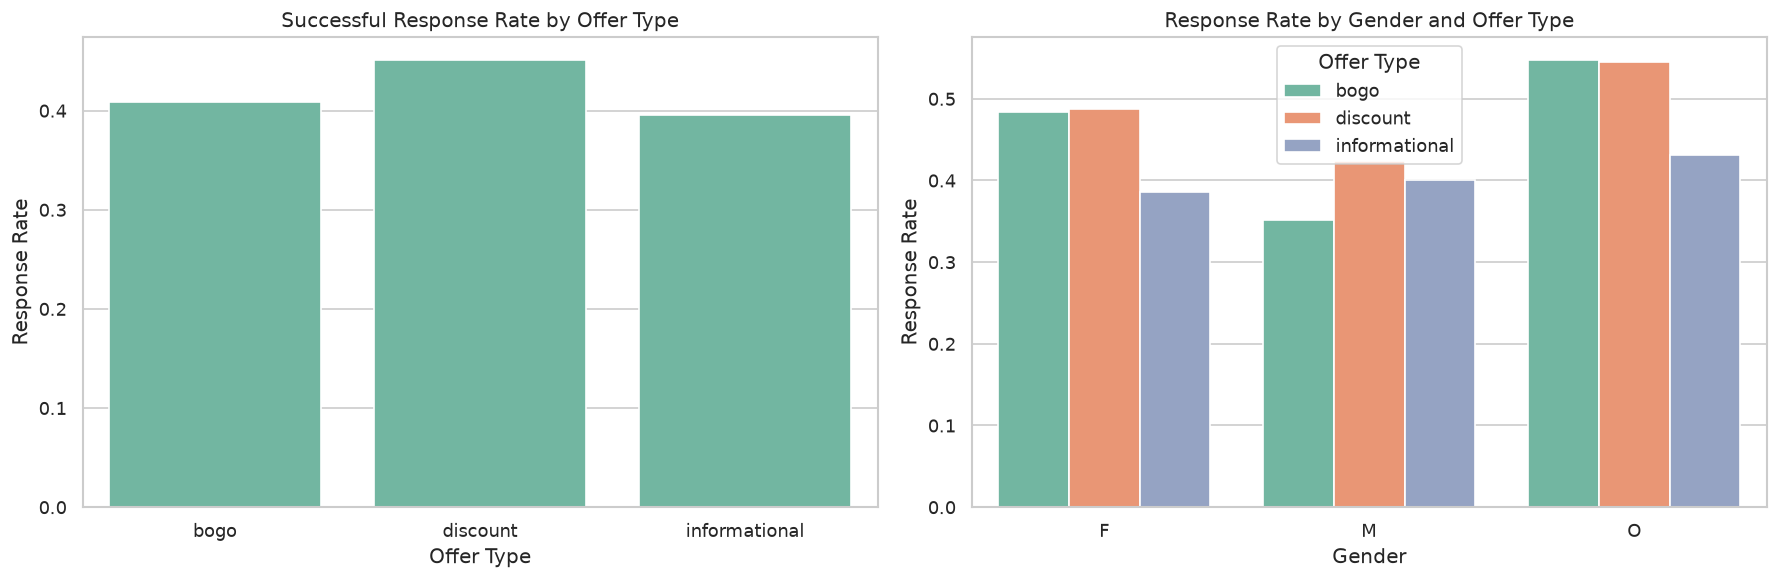

In [7]:
response_by_offer = exposures.groupby(['offer_type', 'offer_id']).agg(
    exposures=('successful_response', 'size'),
    response_rate=('successful_response', 'mean'),
    avg_spend_after_view=('spend_after_view', 'mean'),
).reset_index().sort_values(['offer_type', 'response_rate'], ascending=[True, False])

display(response_by_offer)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=exposures, x='offer_type', y='successful_response', ax=axes[0], errorbar=None)
axes[0].set_title('Successful Response Rate by Offer Type')
axes[0].set_xlabel('Offer Type')
axes[0].set_ylabel('Response Rate')

sns.barplot(data=exposures, x='gender', y='successful_response', hue='offer_type', ax=axes[1], errorbar=None)
axes[1].set_title('Response Rate by Gender and Offer Type')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Response Rate')
axes[1].legend(title='Offer Type')

plt.tight_layout()
plt.show()

        offer_type gender age_group income_group  exposures  response_rate
7             bogo      F     31-45         85k+        130       0.746154
39            bogo      M       76+         85k+        279       0.580645
6             bogo      F     31-45      65k-85k        370       0.562162
27            bogo      M     31-45         85k+        203       0.532020
13            bogo      F     61-75      45k-65k        686       0.527697
67        discount      F     31-45         85k+        125       0.760000
87        discount      M     31-45         85k+        196       0.607143
66        discount      F     31-45      65k-85k        408       0.544118
69        discount      F     46-60      45k-65k        972       0.537037
70        discount      F     46-60      65k-85k       1225       0.530612
125  informational      F     31-45      45k-65k        332       0.530120
129  informational      F     46-60      45k-65k        505       0.477228
126  informational      F

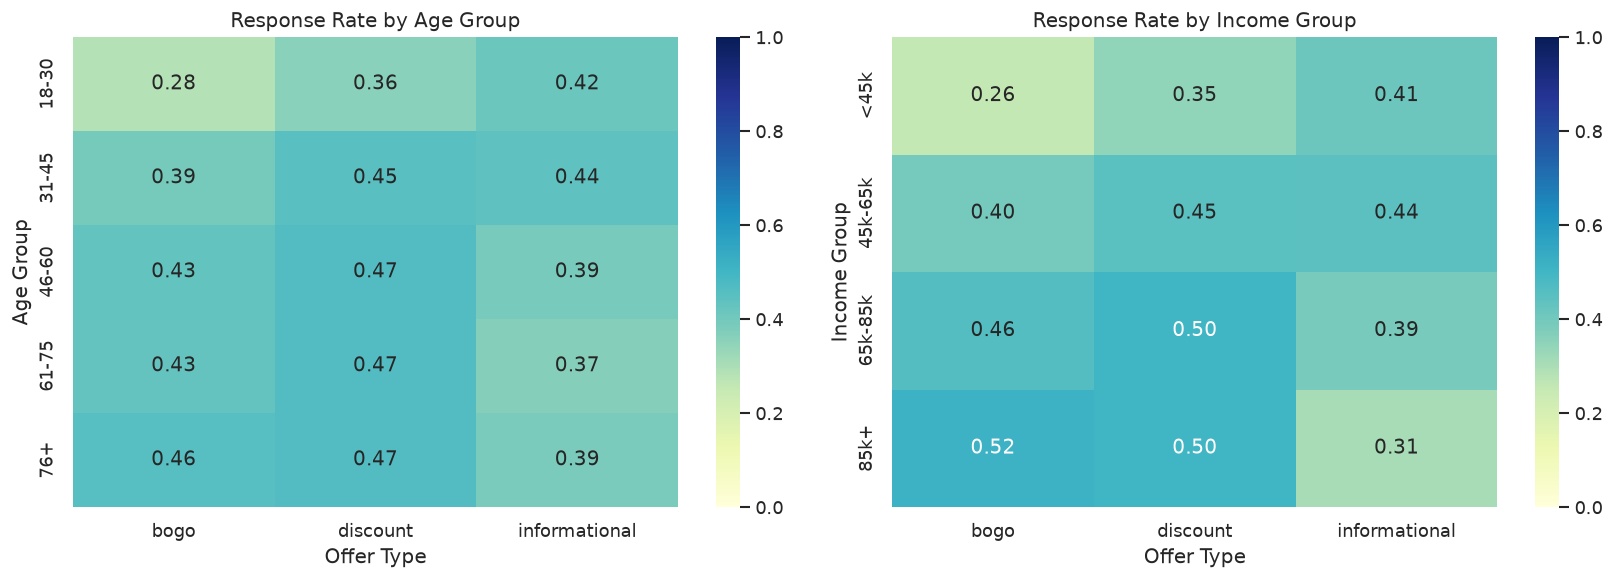

In [8]:
pivot_age = exposures.pivot_table(
    index='age_group', columns='offer_type', values='successful_response', aggfunc='mean', observed=False
)
pivot_income = exposures.pivot_table(
    index='income_group', columns='offer_type', values='successful_response', aggfunc='mean', observed=False
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_age, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Response Rate by Age Group')
axes[0].set_xlabel('Offer Type')
axes[0].set_ylabel('Age Group')

sns.heatmap(pivot_income, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Response Rate by Income Group')
axes[1].set_xlabel('Offer Type')
axes[1].set_ylabel('Income Group')

plt.tight_layout()
plt.show()

best_segments = (
    exposures.groupby(['offer_type', 'gender', 'age_group', 'income_group'], observed=False)
    .agg(exposures=('successful_response', 'size'), response_rate=('successful_response', 'mean'))
    .reset_index()
    .query('exposures >= 100')
    .sort_values(['offer_type', 'response_rate'], ascending=[True, False])
    .groupby('offer_type')
    .head(5)
)

display(best_segments)

# Modeling

The feature matrix intentionally excludes `viewed_offer`, `completed_offer`, transactions after view, and spend after view because those are outcomes observed after the offer is sent. The retained features are customer demographics, membership tenure, offer metadata, and delivery channels.

In [9]:
feature_cols = [
    'gender',
    'age',
    'income',
    'membership_tenure_days',
    'membership_year',
    'age_group',
    'income_group',
    'offer_type',
    'difficulty',
    'duration',
    'reward',
    'channel_email',
    'channel_mobile',
    'channel_social',
    'channel_web',
]

target_col = 'successful_response'
model_data = exposures[feature_cols + [target_col]].dropna().copy()
X = model_data[feature_cols]
y = model_data[target_col]

numeric_features = ['age', 'income', 'membership_tenure_days', 'membership_year', 'difficulty', 'duration', 'reward', 'channel_email', 'channel_mobile', 'channel_social', 'channel_web']
categorical_features = ['gender', 'age_group', 'income_group', 'offer_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocess_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Positive class rate in training:', round(y_train.mean(), 3))

Training rows: 53200
Test rows: 13301
Positive class rate in training: 0.423


In [10]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc,
    }

models = {}
results = []

benchmark = DummyClassifier(strategy='most_frequent')
benchmark.fit(X_train, y_train)
models['Majority benchmark'] = benchmark
results.append(evaluate_model('Majority benchmark', benchmark, X_test, y_test))

logistic = Pipeline(steps=[
    ('preprocess', preprocess_scaled),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
])
logistic.fit(X_train, y_train)
models['Logistic regression'] = logistic
results.append(evaluate_model('Logistic regression', logistic, X_test, y_test))

rf_initial = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
rf_initial.fit(X_train, y_train)
models['Random forest initial'] = rf_initial
results.append(evaluate_model('Random forest initial', rf_initial, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
display(results_df)

                   model  accuracy        f1   roc_auc
2  Random forest initial  0.695061  0.650345  0.757137
1    Logistic regression  0.644613  0.602539  0.705001
0     Majority benchmark  0.576799  0.000000  0.500000


## Refinement

The random forest is refined with a small grid search over tree depth, minimum leaf size, and split size. The grid is intentionally compact because the dataset is moderate in size and the goal is to improve the baseline without overfitting to a large hyperparameter search.

In [11]:
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

param_grid = {
    'classifier__max_depth': [8, 12, None],
    'classifier__min_samples_leaf': [5, 15],
    'classifier__min_samples_split': [10, 30],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

final_model = search.best_estimator_
models['Random forest tuned'] = final_model
results.append(evaluate_model('Random forest tuned', final_model, X_test, y_test))

print('Best parameters:', search.best_params_)
print('Best cross-validation F1:', round(search.best_score_, 4))

evaluation = pd.DataFrame(results).drop_duplicates('model', keep='last').sort_values('f1', ascending=False)
display(evaluation)

Best parameters: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 15, 'classifier__min_samples_split': 10}
Best cross-validation F1: 0.6482
                   model  accuracy        f1   roc_auc
3    Random forest tuned  0.689873  0.657022  0.754709
2  Random forest initial  0.695061  0.650345  0.757137
1    Logistic regression  0.644613  0.602539  0.705001
0     Majority benchmark  0.576799  0.000000  0.500000


# Results

The final model is evaluated on the held-out test set that was not used during training or cross-validation. The confusion matrix and classification report show the balance between finding responders and avoiding unnecessary offers to likely non-responders.

                precision    recall  f1-score   support

not successful       0.76      0.68      0.72      7672
    successful       0.62      0.70      0.66      5629

      accuracy                           0.69     13301
     macro avg       0.69      0.69      0.69     13301
  weighted avg       0.70      0.69      0.69     13301

Final test ROC-AUC: 0.7547


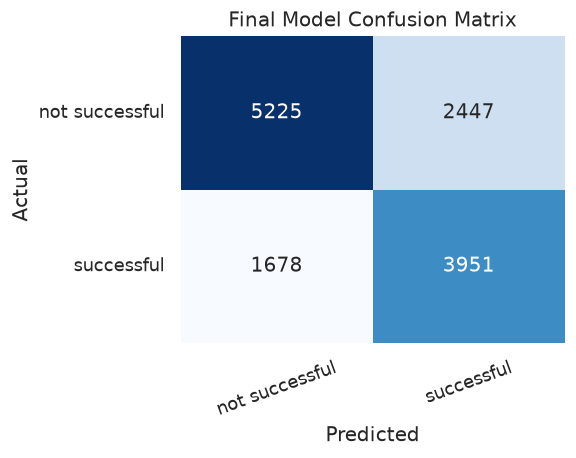

In [12]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['not successful', 'successful']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Final Model Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['not successful', 'successful'], rotation=20)
ax.set_yticklabels(['not successful', 'successful'], rotation=0)
plt.tight_layout()
plt.show()

print('Final test ROC-AUC:', round(roc_auc_score(y_test, y_prob), 4))

                   feature  importance
2   membership_tenure_days    0.214204
9           channel_social    0.212155
3          membership_year    0.101032
1                   income    0.071952
5                 duration    0.058476
4               difficulty    0.058286
6                   reward    0.056756
8           channel_mobile    0.035434
24     offer_type_discount    0.030358
0                      age    0.028813
22       income_group_<45k    0.025781
23         offer_type_bogo    0.022092
12                gender_M    0.016616
11                gender_F    0.013514
10             channel_web    0.013443


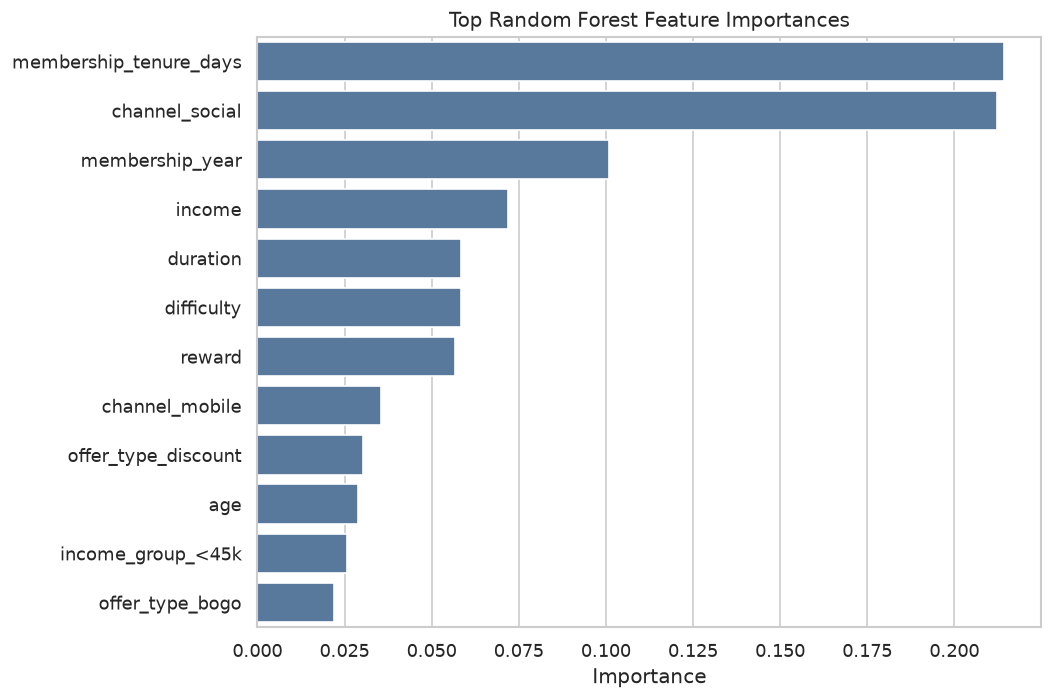

In [13]:
feature_names = numeric_features.copy()
encoder = final_model.named_steps['preprocess'].named_transformers_['cat']
feature_names.extend(encoder.get_feature_names_out(categorical_features))

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': final_model.named_steps['classifier'].feature_importances_,
}).sort_values('importance', ascending=False)

display(importances.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importances.head(12), y='feature', x='importance', ax=ax, color='#4C78A8')
ax.set_title('Top Random Forest Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Final Interpretation

The tuned random forest is the selected model because it improves on the majority-class benchmark and captures non-linear relationships among demographics, membership tenure, and offer structure.

The demographic response tables show which segments respond best to each offer type. In a production targeting workflow, Starbucks could score candidate offers for each customer and send the offer with the highest predicted response probability, while also monitoring incremental lift through A/B testing.

Important limitations remain. The dataset is simulated, it contains only one product category, and the model optimizes response rather than profit or long-term customer value. Some customers may buy without being influenced by an offer, so a causal uplift model would be a stronger next step if randomized holdout data were available.

In [14]:
segment_summary = (
    exposures.groupby(['offer_type', 'gender', 'age_group', 'income_group'], observed=False)
    .agg(exposures=('successful_response', 'size'), response_rate=('successful_response', 'mean'), avg_spend_after_view=('spend_after_view', 'mean'))
    .reset_index()
    .query('exposures >= 100')
    .sort_values(['offer_type', 'response_rate'], ascending=[True, False])
)

top_segment_by_offer = segment_summary.groupby('offer_type').head(3).reset_index(drop=True)
display(top_segment_by_offer)

print('Benchmark F1:', round(evaluation.loc[evaluation['model'] == 'Majority benchmark', 'f1'].iloc[0], 4))
print('Final model F1:', round(evaluation.loc[evaluation['model'] == 'Random forest tuned', 'f1'].iloc[0], 4))
print('F1 improvement:', round(
    evaluation.loc[evaluation['model'] == 'Random forest tuned', 'f1'].iloc[0]
    - evaluation.loc[evaluation['model'] == 'Majority benchmark', 'f1'].iloc[0],
    4,
))

      offer_type gender  ... response_rate avg_spend_after_view
0           bogo      F  ...      0.746154            45.057846
1           bogo      M  ...      0.580645            44.341326
2           bogo      F  ...      0.562162            41.574757
3       discount      F  ...      0.760000            71.338880
4       discount      M  ...      0.607143            62.171173
5       discount      F  ...      0.544118            39.126397
6  informational      F  ...      0.530120            12.014066
7  informational      F  ...      0.477228            12.129446
8  informational      F  ...      0.471429            19.508333

[9 rows x 7 columns]
Benchmark F1: 0.0
Final model F1: 0.657
F1 improvement: 0.657
